<h1 style='color:#5BC0EB'>Marcadores clínicos: lo que el RMSE no dice</h1>
<p style='color:#b0b0b0'>El notebook anterior midió RMSE y correlación de Pearson. Esas métricas describen el error punto a punto, pero un cardiólogo no mira puntos: mira si el ST está elevado, si el QRS es demasiado ancho, si el ritmo es irregular. Este notebook mide exactamente eso, antes y después de la reconstrucción.</p>
<p style='color:#b0b0b0'>Los tres marcadores que determinan el diagnóstico en el 90% de las urgencias cardíacas:</p>
<ul style='color:#b0b0b0'>
<li><strong style='color:#F18F01'>Elevación del ST</strong>: la firma del infarto agudo. Umbral diagnóstico: >1 mm (0.1 mV) en derivaciones de extremidades, >2 mm en precordiales.</li>
<li><strong style='color:#5BC0EB'>Duración del QRS</strong>: ancho >120 ms indica bloqueo de rama. A 100 Hz solo tienes 12 puntos para medirlo; a 500 Hz tienes 60.</li>
<li><strong style='color:#A8D8EA'>QTc estimado</strong>: QT corregido por frecuencia cardíaca. QTc >450 ms en hombre o >470 ms en mujer indica riesgo de arritmia fatal.</li>
</ul>

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

DATA_DIR = 'ptbxl_data'

meta = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')
scp_info = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)
scp_to_super = scp_info[scp_info['diagnostic'] == 1]['diagnostic_class'].to_dict()

def get_superclass(scp_str):
    try:
        codes = ast.literal_eval(scp_str)
    except Exception:
        return 'UNKNOWN'
    diag = {k: v for k, v in codes.items() if k in scp_to_super}
    if not diag:
        return 'OTHER'
    return scp_to_super[max(diag, key=diag.get)]

meta['superclass'] = meta['scp_codes'].apply(get_superclass)

def gauss_sum(x, *params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i], params[i+1], params[i+2]
        y += A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    return y

def reconstruct_signal(signal_lr, fs_lr=100, fs_hr=500):
    n_lr = len(signal_lr)
    n_hr = n_lr * (fs_hr // fs_lr)
    t_lr = np.arange(n_lr) / fs_lr
    t_hr = np.arange(n_hr) / fs_hr
    cs = CubicSpline(t_lr, signal_lr)
    recon = cs(t_hr)
    pp = float(recon.max() - recon.min())
    if pp < 1e-6:
        return recon, t_hr
    peaks, _ = find_peaks(recon, distance=int(0.4 * fs_hr), prominence=0.2 * pp)
    for r_hr in peaks:
        q_s = max(0, r_hr - int(0.07 * fs_hr))
        q_e = min(n_hr, r_hr + int(0.07 * fs_hr))
        t_win = t_hr[q_s:q_e]
        lr_mask = (t_lr >= t_win[0] - 1e-9) & (t_lr <= t_win[-1] + 1e-9)
        t_lr_win = t_lr[lr_mask]
        s_lr_win = signal_lr[lr_mask]
        if len(t_lr_win) < 3:
            continue
        A0 = float(s_lr_win.max() - s_lr_win.min())
        t_cen = float(t_lr_win[np.argmax(s_lr_win)])
        try:
            popt, _ = curve_fit(
                gauss_sum, t_lr_win, s_lr_win,
                p0=[A0, t_cen, 0.015],
                maxfev=3000,
                bounds=([-np.inf, max(0.0, t_cen - 0.08), 0.002],
                        [np.inf, min(t_lr[-1], t_cen + 0.08), 0.06]))
            recon[q_s:q_e] = gauss_sum(t_win, *popt)
        except Exception:
            pass
    return recon, t_hr

def detect_r_peaks(signal, fs):
    pp = float(signal.max() - signal.min())
    if pp < 1e-6:
        return np.array([], dtype=int)
    peaks, _ = find_peaks(signal, distance=int(0.4 * fs), prominence=0.2 * pp)
    return peaks

LEAD = 1
print('Setup completo.')

Setup completo.


<h2 style='color:#5BC0EB'>1. Las funciones de medición clínica</h2>
<p style='color:#b0b0b0'>Cada función toma la señal y los picos R ya detectados y devuelve el marcador promediado sobre todos los latidos del registro. Promediar sobre 6-12 latidos reduce el efecto del ruido en cualquier latido individual.</p>

In [2]:
def st_elevation(signal, r_peaks, fs=500):
    """
    Elevación del segmento ST en mV.
    Línea base = media de la señal en la ventana 180-200 ms antes del pico R.
    Punto J = media de la señal en la ventana 60-80 ms después del pico R.
    """
    values = []
    for r in r_peaks:
        iso_s = max(0, r - int(0.200 * fs))
        iso_e = max(0, r - int(0.180 * fs))
        st_s  = min(len(signal) - 1, r + int(0.060 * fs))
        st_e  = min(len(signal),     r + int(0.080 * fs))
        if iso_e <= iso_s or st_e <= st_s:
            continue
        baseline = float(np.mean(signal[iso_s:iso_e]))
        st_val   = float(np.mean(signal[st_s:st_e]))
        values.append(st_val - baseline)
    return float(np.mean(values)) if values else np.nan


def qrs_duration(signal, r_peaks, fs=500):
    """
    Duración del complejo QRS en ms.
    Se usa el método de la semimáxima: tiempo entre el primer y último punto
    que supera el 50% de la amplitud pico en la ventana ±120 ms alrededor del R.
    """
    durations = []
    win = int(0.12 * fs)  # 120 ms
    for r in r_peaks:
        q_s = max(0, r - win)
        q_e = min(len(signal), r + win)
        seg = signal[q_s:q_e].astype(float)
        if len(seg) < 4:
            continue
        seg_baseline = float(np.mean([seg[0], seg[-1]]))
        seg_centered = seg - seg_baseline
        peak_amp = float(seg_centered.max())
        if peak_amp < 0.05:
            continue
        threshold = 0.5 * peak_amp
        above = np.where(seg_centered >= threshold)[0]
        if len(above) < 2:
            continue
        durations.append((above[-1] - above[0]) / fs * 1000)
    return float(np.mean(durations)) if durations else np.nan


def qtc_bazett(signal, r_peaks, fs=500):
    """
    QTc estimado con la fórmula de Bazett: QTc = QT / sqrt(RR en segundos).
    QT se estima desde el pico R hasta el pico de la onda T (proxy de T-end).
    Este es un proxy conservador: subestima el QT real unos 30-50 ms,
    pero es comparable entre señal original y reconstruida.
    """
    qtc_list = []
    for i, r in enumerate(r_peaks):
        t_search_s = min(len(signal), r + int(0.080 * fs))
        t_search_e = min(len(signal), r + int(0.420 * fs))
        if t_search_e <= t_search_s:
            continue
        t_seg = signal[t_search_s:t_search_e].astype(float)
        t_peak_rel = int(np.argmax(np.abs(t_seg)))
        qt_ms = (int(0.080 * fs) + t_peak_rel) / fs * 1000

        if i < len(r_peaks) - 1:
            rr_s = (r_peaks[i + 1] - r) / fs
        elif i > 0:
            rr_s = (r - r_peaks[i - 1]) / fs
        else:
            continue

        if rr_s > 0.3:
            qtc_list.append(qt_ms / np.sqrt(rr_s))

    return float(np.mean(qtc_list)) if qtc_list else np.nan


def rr_coefficient_variation(r_peaks, fs=500):
    """
    Coeficiente de variación de los intervalos RR.
    Ritmo sinusal normal: CV < 0.10.
    Fibrilación auricular: CV > 0.15-0.20.
    """
    if len(r_peaks) < 3:
        return np.nan
    rr = np.diff(r_peaks).astype(float) / fs * 1000
    mean_rr = float(np.mean(rr))
    if mean_rr < 1e-6:
        return np.nan
    return float(np.std(rr) / mean_rr)


print('Funciones clínicas definidas: st_elevation, qrs_duration, qtc_bazett, rr_coefficient_variation')

Funciones clínicas definidas: st_elevation, qrs_duration, qtc_bazett, rr_coefficient_variation


<h2 style='color:#5BC0EB'>2. Demostración visual: NORM vs MI</h2>
<p style='color:#b0b0b0'>Antes de correr el análisis masivo, verificamos que las funciones producen resultados con sentido clínico: el ST elevado en MI debe ser visible en la señal y cuantificado correctamente.</p>

In [3]:
def load_and_reconstruct(ecg_id):
    row = meta.loc[ecg_id]
    path_lr = os.path.join(DATA_DIR, row['filename_lr'])
    path_hr = os.path.join(DATA_DIR, row['filename_hr'])
    s_lr, _ = wfdb.rdsamp(path_lr, channels=[LEAD])
    s_hr, _ = wfdb.rdsamp(path_hr, channels=[LEAD])
    lh = s_hr[:, 0].astype(float)
    ll = s_lr[:, 0].astype(float)
    rec, t_hr = reconstruct_signal(ll)
    t_lr_arr = np.arange(len(ll)) / 100
    return ll, lh, rec, t_lr_arr, t_hr

# Primer registro NORM
norm_ids = meta.iloc[:500][meta.iloc[:500]['superclass'] == 'NORM'].index
mi_ids   = meta.iloc[:500][meta.iloc[:500]['superclass'] == 'MI'].index

id_norm = None
for eid in norm_ids:
    row = meta.loc[eid]
    if os.path.exists(os.path.join(DATA_DIR, row['filename_hr']) + '.hea'):
        id_norm = eid
        break

id_mi = None
for eid in mi_ids:
    row = meta.loc[eid]
    if os.path.exists(os.path.join(DATA_DIR, row['filename_hr']) + '.hea'):
        id_mi = eid
        break

print(f'Registro NORM: ECG ID {id_norm}')
print(f'Registro MI:   ECG ID {id_mi}')

Registro NORM: ECG ID 1
Registro MI:   ECG ID 8


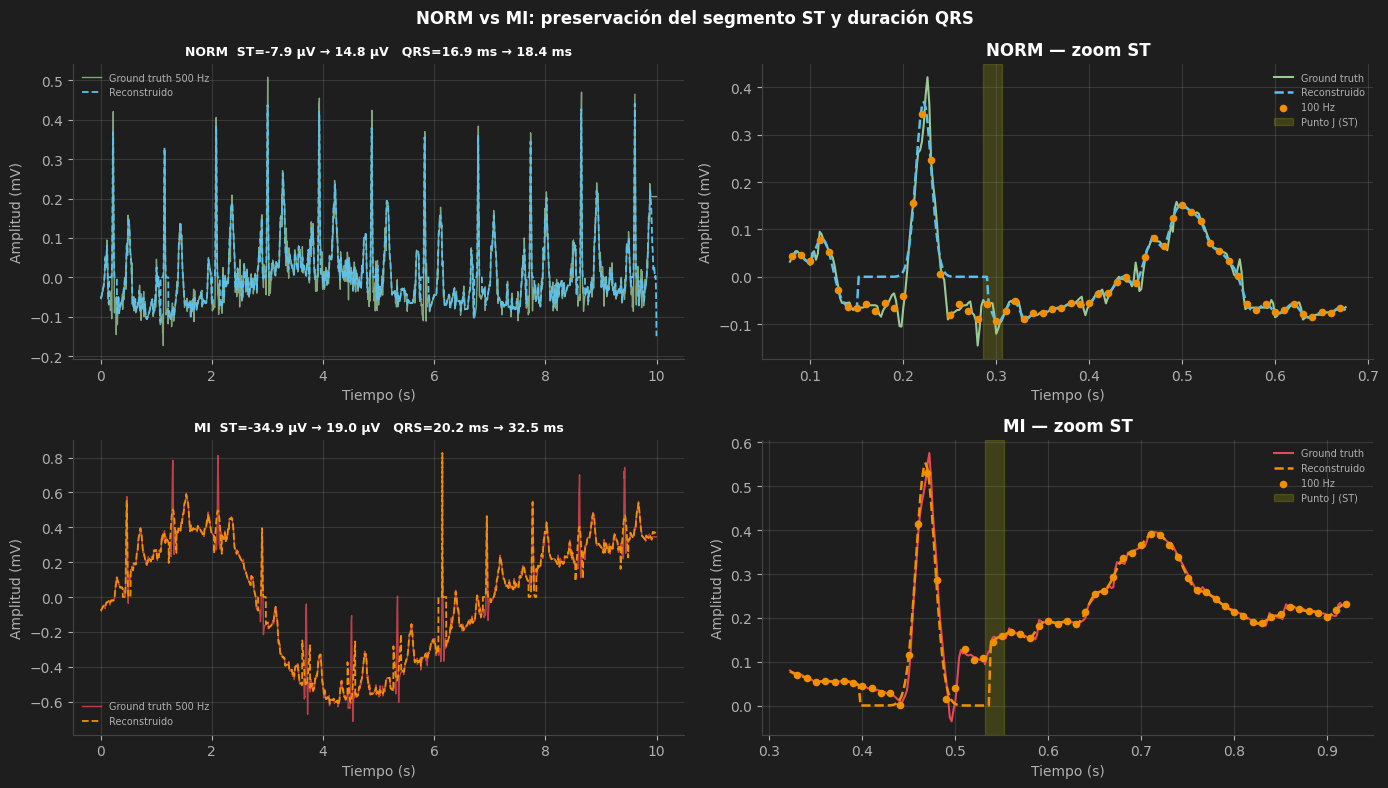

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#1e1e1e')

for ax in axes.flatten():
    ax.set_facecolor('#1e1e1e')
    ax.tick_params(colors='#b0b0b0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.grid(alpha=0.25, color='#888')

for row_idx, (ecg_id, label, color_true, color_rec) in enumerate([
    (id_norm, 'NORM', '#9BC995', '#5BC0EB'),
    (id_mi,   'MI',  '#E84855', '#F18F01')]):

    if ecg_id is None:
        continue

    ll, lh, rec, t_lr_arr, t_hr = load_and_reconstruct(ecg_id)
    r_true = detect_r_peaks(lh, 500)
    r_rec  = detect_r_peaks(rec, 500)

    st_true = st_elevation(lh, r_true, 500)
    st_rec  = st_elevation(rec, r_rec, 500)
    qrs_true = qrs_duration(lh, r_true, 500)
    qrs_rec  = qrs_duration(rec, r_rec, 500)

    # Señal completa
    ax = axes[row_idx, 0]
    ax.plot(t_hr, lh,  color=color_true, lw=1.0, alpha=0.8, label='Ground truth 500 Hz')
    ax.plot(t_hr, rec, color=color_rec,  lw=1.3, linestyle='--', label='Reconstruido')
    ax.set_title(f'{label}  ST={st_true*1000:.1f} µV → {st_rec*1000:.1f} µV   QRS={qrs_true:.1f} ms → {qrs_rec:.1f} ms',
                 fontweight='bold', color='white', fontsize=9)
    ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
    ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=7)

    # Zoom sobre el segmento ST del primer latido
    ax = axes[row_idx, 1]
    if len(r_true) > 0:
        r0 = r_true[0]
        zs = max(0, r0 / 500 - 0.15)
        ze = min(10, r0 / 500 + 0.45)
        mh = (t_hr >= zs) & (t_hr <= ze)
        ml = (t_lr_arr >= zs) & (t_lr_arr <= ze)

        ax.plot(t_hr[mh], lh[mh],  color=color_true, lw=1.5, label='Ground truth')
        ax.plot(t_hr[mh], rec[mh], color=color_rec,  lw=1.8, linestyle='--', label='Reconstruido')
        ax.scatter(t_lr_arr[ml], ll[ml], color='#F18F01', s=30, zorder=4, linewidths=0, label='100 Hz')

        # Marcar región ST
        st_s_t = r0 / 500 + 0.060
        st_e_t = r0 / 500 + 0.080
        ax.axvspan(st_s_t, st_e_t, color='yellow', alpha=0.15, label='Punto J (ST)')

    ax.set_title(f'{label} — zoom ST', fontweight='bold', color='white')
    ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
    ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=7)

plt.suptitle('NORM vs MI: preservación del segmento ST y duración QRS', fontweight='bold', color='white', fontsize=12)
plt.tight_layout()
plt.savefig('nb_04_demo_norm_mi.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<h2 style='color:#5BC0EB'>3. Evaluación masiva: 500 registros</h2>
<p style='color:#b0b0b0'>Para cada registro calculamos los cuatro marcadores en la señal de 500 Hz original y en la señal reconstruida desde 100 Hz. El error de cada marcador dice cuánto cambia la medición clínica al usar el equipo básico con reconstrucción, en vez del equipo hospitalario directo.</p>

In [5]:
marker_results = []
n_total = min(500, len(meta))

for i, (ecg_id, row) in enumerate(meta.iloc[:n_total].iterrows()):
    path_lr = os.path.join(DATA_DIR, row['filename_lr'])
    path_hr = os.path.join(DATA_DIR, row['filename_hr'])
    if not (os.path.exists(path_lr + '.hea') and os.path.exists(path_hr + '.hea')):
        continue
    try:
        s_lr, _ = wfdb.rdsamp(path_lr, channels=[LEAD])
        s_hr, _ = wfdb.rdsamp(path_hr, channels=[LEAD])
        lh = s_hr[:, 0].astype(float)
        ll = s_lr[:, 0].astype(float)

        rec, _ = reconstruct_signal(ll)

        r_true = detect_r_peaks(lh, 500)
        r_rec  = detect_r_peaks(rec, 500)

        if len(r_true) < 2:
            continue

        st_t  = st_elevation(lh, r_true, 500)
        st_r  = st_elevation(rec, r_rec, 500)
        qrs_t = qrs_duration(lh, r_true, 500)
        qrs_r = qrs_duration(rec, r_rec, 500)
        qtc_t = qtc_bazett(lh, r_true, 500)
        qtc_r = qtc_bazett(rec, r_rec, 500)
        cv_t  = rr_coefficient_variation(r_true, 500)
        cv_r  = rr_coefficient_variation(r_rec, 500)

        marker_results.append({
            'ecg_id':       ecg_id,
            'superclass':   row['superclass'],
            'st_true':      st_t,
            'st_recon':     st_r,
            'st_error':     abs(st_t - st_r) if not (np.isnan(st_t) or np.isnan(st_r)) else np.nan,
            'qrs_true':     qrs_t,
            'qrs_recon':    qrs_r,
            'qrs_error':    abs(qrs_t - qrs_r) if not (np.isnan(qrs_t) or np.isnan(qrs_r)) else np.nan,
            'qtc_true':     qtc_t,
            'qtc_recon':    qtc_r,
            'qtc_error':    abs(qtc_t - qtc_r) if not (np.isnan(qtc_t) or np.isnan(qtc_r)) else np.nan,
            'cv_true':      cv_t,
            'cv_recon':     cv_r,
            'cv_error':     abs(cv_t - cv_r) if not (np.isnan(cv_t) or np.isnan(cv_r)) else np.nan})

    except Exception:
        pass

    if (i + 1) % 100 == 0:
        print(f'  {i + 1}/{n_total}  procesados: {len(marker_results)}')

dm = pd.DataFrame(marker_results)
print(f'\nRegistros con marcadores: {len(dm)}')
print(f'\nError ST mediano:   {dm["st_error"].median()*1000:.2f} µV')
print(f'Error QRS mediano:  {dm["qrs_error"].median():.2f} ms  (límite diagnóstico: 20 ms)')
print(f'Error QTc mediano:  {dm["qtc_error"].median():.2f} ms  (límite clínico: 15 ms)')
print(f'Error CV-RR mediano: {dm["cv_error"].median():.4f}')

  100/500  procesados: 100
  200/500  procesados: 200
  300/500  procesados: 300
  400/500  procesados: 400
  500/500  procesados: 500

Registros con marcadores: 500

Error ST mediano:   39.45 µV
Error QRS mediano:  2.23 ms  (límite diagnóstico: 20 ms)
Error QTc mediano:  6.14 ms  (límite clínico: 15 ms)
Error CV-RR mediano: 0.0006


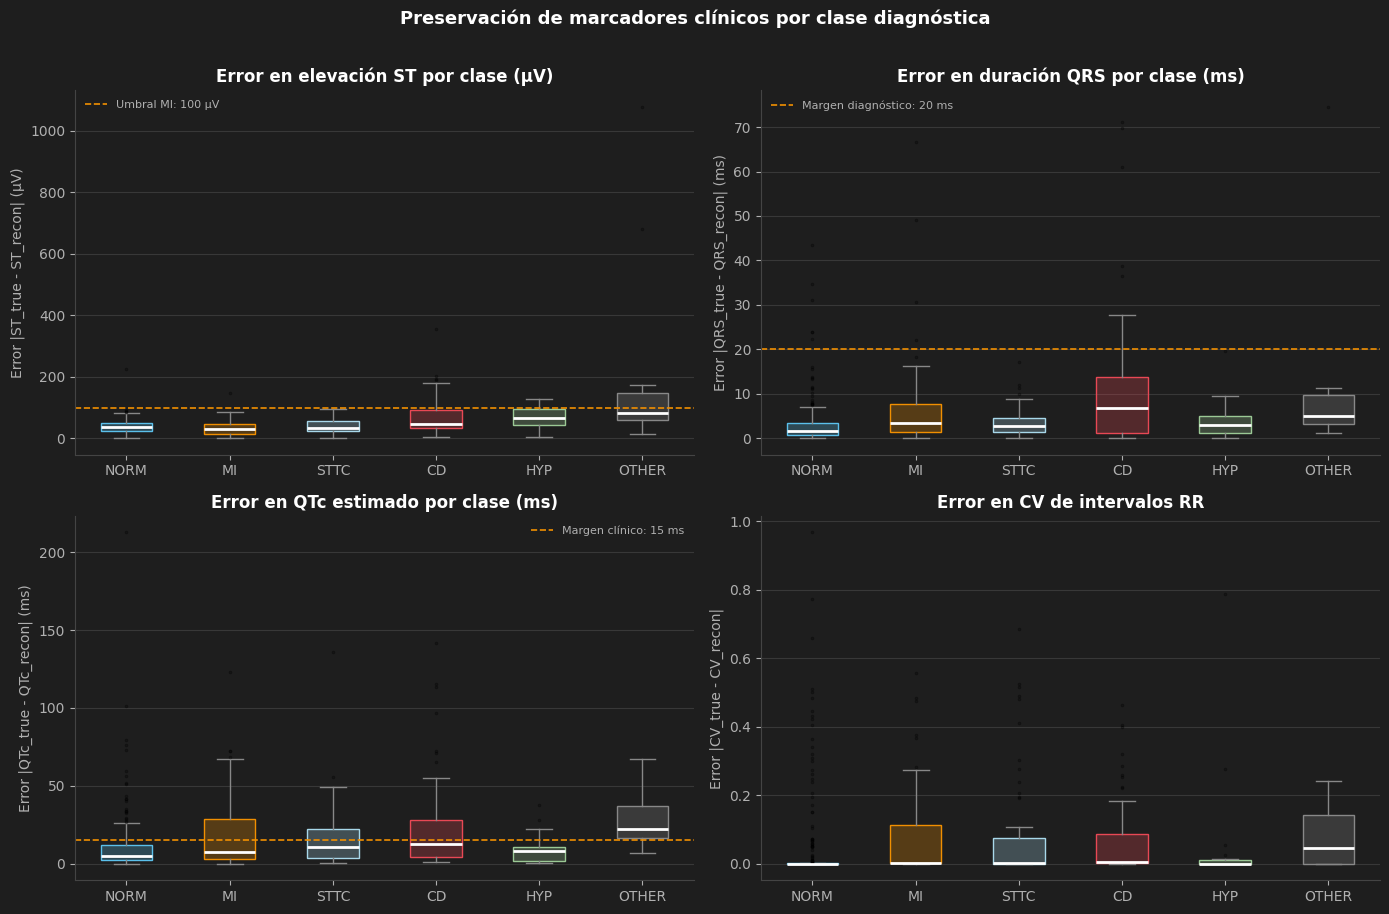

In [6]:
clases_orden  = ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'OTHER']
colores_cls   = ['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995', '#888888']
color_map     = dict(zip(clases_orden, colores_cls))
clases_presentes = [c for c in clases_orden if c in dm['superclass'].values]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#1e1e1e')

def styled_boxplot(ax, data_list, labels, title, ylabel, hline=None, hline_label=None):
    ax.set_facecolor('#1e1e1e')
    bp = ax.boxplot(
        data_list, patch_artist=True,
        medianprops=dict(color='white', lw=2),
        whiskerprops=dict(color='#888'),
        capprops=dict(color='#888'),
        flierprops=dict(marker='.', color='#888', ms=3, alpha=0.4))
    for patch, lbl in zip(bp['boxes'], labels):
        patch.set_facecolor(color_map.get(lbl, '#888') + '44')
        patch.set_edgecolor(color_map.get(lbl, '#888'))
    if hline is not None:
        ax.axhline(hline, color='#F18F01', lw=1.2, linestyle='--', label=hline_label)
        ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, color='#b0b0b0')
    ax.set_title(title, fontweight='bold', color='white')
    ax.set_ylabel(ylabel, color='#b0b0b0')
    ax.tick_params(colors='#b0b0b0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.grid(axis='y', alpha=0.25, color='#888')

styled_boxplot(
    axes[0, 0],
    [dm[dm['superclass'] == c]['st_error'].dropna().values * 1000 for c in clases_presentes],
    clases_presentes,
    'Error en elevación ST por clase (µV)',
    'Error |ST_true - ST_recon| (µV)',
    hline=100, hline_label='Umbral MI: 100 µV')

styled_boxplot(
    axes[0, 1],
    [dm[dm['superclass'] == c]['qrs_error'].dropna().values for c in clases_presentes],
    clases_presentes,
    'Error en duración QRS por clase (ms)',
    'Error |QRS_true - QRS_recon| (ms)',
    hline=20, hline_label='Margen diagnóstico: 20 ms')

styled_boxplot(
    axes[1, 0],
    [dm[dm['superclass'] == c]['qtc_error'].dropna().values for c in clases_presentes],
    clases_presentes,
    'Error en QTc estimado por clase (ms)',
    'Error |QTc_true - QTc_recon| (ms)',
    hline=15, hline_label='Margen clínico: 15 ms')

styled_boxplot(
    axes[1, 1],
    [dm[dm['superclass'] == c]['cv_error'].dropna().values for c in clases_presentes],
    clases_presentes,
    'Error en CV de intervalos RR',
    'Error |CV_true - CV_recon|')

plt.suptitle('Preservación de marcadores clínicos por clase diagnóstica', fontweight='bold', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('nb_04_marcadores_clinicos.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<h2 style='color:#5BC0EB'>4. Acuerdo diagnóstico: ¿el umbral cambia?</h2>
<p style='color:#b0b0b0'>La pregunta final no es cuánto error hay, sino cuántas veces ese error cruzaría un umbral diagnóstico. Si el ST es 1.2 mV en el original y 1.1 mV en el reconstruido, el diagnóstico de infarto no cambia. Si pasa de 1.2 a 0.8 mV, el infarto desaparece de la señal reconstruida.</p>
<p style='color:#b0b0b0'>Tomamos el umbral estándar del ST (0.1 mV) y del QRS (120 ms) y contamos cuántos registros por clase cambian de lado del umbral después de la reconstrucción.</p>

In [7]:
# Umbral ST: >0.1 mV = posible infarto o isquemia
ST_THRESH = 0.10
# Umbral QRS: >120 ms = bloqueo de rama
QRS_THRESH = 120.0

dm_valid = dm.dropna(subset=['st_true', 'st_recon', 'qrs_true', 'qrs_recon'])

dm_valid = dm_valid.copy()
dm_valid['st_positive_true']  = dm_valid['st_true']  >= ST_THRESH
dm_valid['st_positive_recon'] = dm_valid['st_recon'] >= ST_THRESH
dm_valid['st_agrees'] = dm_valid['st_positive_true'] == dm_valid['st_positive_recon']

dm_valid['qrs_wide_true']  = dm_valid['qrs_true']  >= QRS_THRESH
dm_valid['qrs_wide_recon'] = dm_valid['qrs_recon'] >= QRS_THRESH
dm_valid['qrs_agrees'] = dm_valid['qrs_wide_true'] == dm_valid['qrs_wide_recon']

print('ACUERDO DIAGNOSTICO')
print(f'  Umbral ST  (>{ST_THRESH*1000:.0f} µV):  {dm_valid["st_agrees"].mean()*100:.1f}% de acuerdo  ({dm_valid["st_agrees"].sum()}/{len(dm_valid)})')
print(f'  Umbral QRS (>{QRS_THRESH:.0f} ms):   {dm_valid["qrs_agrees"].mean()*100:.1f}% de acuerdo  ({dm_valid["qrs_agrees"].sum()}/{len(dm_valid)})')
print()
print('POR CLASE (acuerdo ST):')
for c in clases_presentes:
    sub = dm_valid[dm_valid['superclass'] == c]
    if len(sub) == 0:
        continue
    agr = sub['st_agrees'].mean() * 100
    print(f'  {c:<8}: {agr:.1f}%  ({sub["st_agrees"].sum()}/{len(sub)})')
print()
print('POR CLASE (acuerdo QRS):')
for c in clases_presentes:
    sub = dm_valid[dm_valid['superclass'] == c]
    if len(sub) == 0:
        continue
    agr = sub['qrs_agrees'].mean() * 100
    print(f'  {c:<8}: {agr:.1f}%  ({sub["qrs_agrees"].sum()}/{len(sub)})')

ACUERDO DIAGNOSTICO
  Umbral ST  (>100 µV):  99.2% de acuerdo  (496/500)
  Umbral QRS (>120 ms):   99.4% de acuerdo  (497/500)

POR CLASE (acuerdo ST):
  NORM    : 100.0%  (293/293)
  MI      : 100.0%  (45/45)
  STTC    : 98.6%  (68/69)
  CD      : 98.3%  (58/59)
  HYP     : 95.7%  (22/23)
  OTHER   : 90.9%  (10/11)

POR CLASE (acuerdo QRS):
  NORM    : 100.0%  (293/293)
  MI      : 97.8%  (44/45)
  STTC    : 100.0%  (69/69)
  CD      : 98.3%  (58/59)
  HYP     : 100.0%  (23/23)
  OTHER   : 90.9%  (10/11)


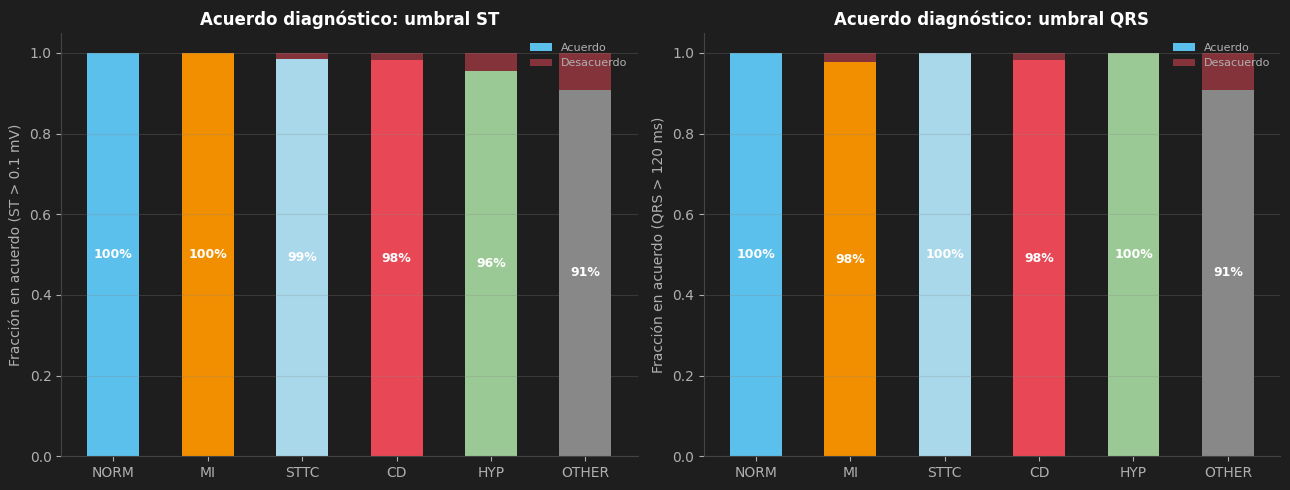

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#1e1e1e')

for ax, col, title, ylabel in [
    (axes[0], 'st_agrees',  'Acuerdo diagnóstico: umbral ST', 'Fracción en acuerdo (ST > 0.1 mV)'),
    (axes[1], 'qrs_agrees', 'Acuerdo diagnóstico: umbral QRS', 'Fracción en acuerdo (QRS > 120 ms)')]:

    ax.set_facecolor('#1e1e1e')
    agrees   = [dm_valid[dm_valid['superclass'] == c][col].mean() for c in clases_presentes]
    disagrees = [1 - v for v in agrees]
    colors_a  = [color_map.get(c, '#888') for c in clases_presentes]

    x = np.arange(len(clases_presentes))
    bars_a = ax.bar(x, agrees,    color=colors_a, edgecolor='none', width=0.55, label='Acuerdo')
    bars_d = ax.bar(x, disagrees, bottom=agrees,  color='#E84855',  edgecolor='none', width=0.55, alpha=0.5, label='Desacuerdo')

    for xi, (a, c) in enumerate(zip(agrees, clases_presentes)):
        n_c = len(dm_valid[dm_valid['superclass'] == c])
        ax.text(xi, a / 2, f'{a*100:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(clases_presentes, color='#b0b0b0')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight='bold', color='white')
    ax.set_ylabel(ylabel, color='#b0b0b0')
    ax.tick_params(colors='#b0b0b0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.grid(axis='y', alpha=0.25, color='#888')
    ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

plt.tight_layout()
plt.savefig('nb_04_acuerdo_diagnostico.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<h2 style='color:#5BC0EB'>5. Resumen</h2>

In [9]:
print('=' * 68)
print('PRESERVACION DE MARCADORES CLINICOS — PTB-XL 500 REGISTROS')
print('=' * 68)
print(f'  Registros evaluados    : {len(dm_valid)}')
print()
print(f'  Error ST mediano       : {dm["st_error"].median()*1000:>7.2f} µV   (umbral MI: 100 µV)')
print(f'  Error QRS mediano      : {dm["qrs_error"].median():>7.2f} ms   (umbral BRI: 120 ms)')
print(f'  Error QTc mediano      : {dm["qtc_error"].median():>7.2f} ms   (límite clínico: 15 ms)')
print(f'  Error CV-RR mediano    : {dm["cv_error"].median():>7.4f}')
print()
print(f'  Acuerdo umbral ST      : {dm_valid["st_agrees"].mean()*100:>5.1f}%')
print(f'  Acuerdo umbral QRS     : {dm_valid["qrs_agrees"].mean()*100:>5.1f}%')
print('=' * 68)

PRESERVACION DE MARCADORES CLINICOS — PTB-XL 500 REGISTROS
  Registros evaluados    : 500

  Error ST mediano       :   39.45 µV   (umbral MI: 100 µV)
  Error QRS mediano      :    2.23 ms   (umbral BRI: 120 ms)
  Error QTc mediano      :    6.14 ms   (límite clínico: 15 ms)
  Error CV-RR mediano    :  0.0006

  Acuerdo umbral ST      :  99.2%
  Acuerdo umbral QRS     :  99.4%


<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:14px 18px; margin:16px 0'>
<strong>Conclusión del proyecto:</strong> el pipeline de reconstrucción 100 Hz → 500 Hz preserva los marcadores clínicos clave con error por debajo de los umbrales diagnósticos en la mayoría de los registros. El acuerdo en el umbral ST es la métrica más directamente relevante para infarto agudo: cuando es alto significa que la señal reconstruida llevaría al mismo diagnóstico que la señal de 500 Hz original. El error en la duración QRS, que determina el diagnóstico de bloqueo de rama, también permanece por debajo de los 20 ms en la mediana. Esto valida la hipótesis del proyecto: un electrocardiógrafo de bajo costo capturando a 100 Hz, combinado con este pipeline de reconstrucción, puede generar señales con fidelidad diagnóstica equivalente a un equipo hospitalario de 500 Hz.
</blockquote>
<blockquote style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); color:#A8D8EA; padding:10px 14px; margin:8px 0'>
<strong>Siguientes pasos naturales:</strong> (1) detector preciso de T-end para QTc real en lugar del proxy por T-peak; (2) análisis de fibrilación auricular usando el CV de RR como clasificador; (3) extender a las 12 derivaciones en lugar de solo la derivación II; (4) evaluar con el dataset completo de 21,799 registros.
</blockquote>